# Electric vehicle with premise: a compact time-explicit LCA

This notebook is a compact walk-through of a time-explicit LCA with `bw_timex`, using a cradle-to-grave case study of an electric vehicle (ev). The case study is simplified: it is not meant to reflect the complexity of electric mobility, but to show what you need to do to make an LCA time-explicit.

> **Note:** This notebook uses ecoinvent and premise data. It expects a brightway project with ecoinvent v3.12 (cutoff) and prospective databases for 2020, 2030 and 2040, created from it with [`premise`](https://github.com/polca/premise) (all sectors updated, REMIND-EU SSP2-NDC). If you don't have access to that, please check out the ["from scratch" version](../tutorials/2_electric_vehicle_from_scratch.ipynb) of this notebook, which makes up all its data. A more detailed version of this example, which explains all the modelling steps and the additional options of `bw_timex`, is [here](./electric_vehicle_premise_detailed.ipynb).

In [1]:
import bw2data as bd

bd.projects.set_current("ei312_REMIND_EU")

## The product system

Our ev is built from a glider, a powertrain and a battery, it is driven for 150,000 km over 15 years, and its parts are treated at the end of life. Purple boxes are foreground, cyan boxes come from the background databases (ecoinvent/premise).

```mermaid
flowchart LR
    glider_production(glider production):::ei-->ev_production
    powertrain_production(powertrain production):::ei-->ev_production
    battery_production(battery production):::ei-->ev_production
    ev_production(ev production):::fg-->driving
    electricity_generation(electricity generation):::ei-->driving
    driving(driving):::fg-->used_ev
    used_ev(used ev):::fg-->glider_eol(glider eol):::ei
    used_ev-->powertrain_eol(powertrain eol):::ei
    used_ev-->battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

Building this system is standard brightway modelling, without anything `bw_timex`-specific, so the cell below just does it in one go (unfold it if you are curious).

In [2]:
# Standard brightway modelling of the ev system - nothing time-explicit yet.

ELECTRICITY_CONSUMPTION = 0.2  # kWh/km
MILEAGE = 150_000  # km
LIFETIME = 15  # years
MASS_GLIDER = 840  # kg
MASS_POWERTRAIN = 80  # kg
MASS_BATTERY = 280  # kg

db_2020 = bd.Database("ei312_REMIND-EU_SSP2_NDC_2020")
db_2030 = bd.Database("ei312_REMIND-EU_SSP2_NDC_2030")
db_2040 = bd.Database("ei312_REMIND-EU_SSP2_NDC_2040")

# Older versions of this notebook wrote the "without EOL" copies directly into the
# premise databases above. If you ran one of those versions, those leftover copies are
# still there, and they now share their (name, reference product, location) with the
# copies this notebook creates below in ev_background_<year> - same date, different
# database. bw_timex would then refuse to resolve the resulting ambiguity. This cleanup
# is safe: these nodes were created by this notebook, not premise.
for db in [db_2020, db_2030, db_2040]:
    for code_ in [
        "glider_production_without_eol",
        "powertrain_production_without_eol",
        "battery_production_without_eol",
    ]:
        try:
            db.get(code=code_).delete()
        except Exception:
            pass

# The ecoinvent processes for the ev parts already contain their end-of-life treatment.
# We want to model the end of life separately, so we create copies without it. Those
# copies live in our own databases - one per point in time - so the premise databases
# stay untouched. bw_timex allows several databases to share a date.
modified_dbs = {}
for db in [db_2020, db_2030, db_2040]:
    year = db.name[-4:]
    modified_name = f"ev_background_{year}"
    if modified_name in bd.databases:
        del bd.databases[modified_name]
    modified_db = bd.Database(modified_name)
    modified_db.register()
    modified_dbs[db.name] = modified_db

    for name, code_, eol_name in [
        (
            "glider production, passenger car",
            "glider_production_without_eol",
            "market for used glider, passenger car",
        ),
        (
            "powertrain production, for electric passenger car",
            "powertrain_production_without_eol",
            "market for used powertrain from electric passenger car, manual dismantling",
        ),
        # For the battery, some waste treatment is buried in the cell production.
        # For simplicity, we just leave it in there.
        (
            "battery production, Li-ion, LiMn2O4, rechargeable",
            "battery_production_without_eol",
            None,
        ),
    ]:
        without_eol = db.get(name=name).copy(code=code_, database=modified_name)
        without_eol["name"] = f"{name}, without EOL"
        without_eol.save()
        if eol_name:
            for exc in without_eol.exchanges():
                if exc.input["name"] == eol_name:
                    exc.delete()

    modified_db.process()

# Background processes our foreground links to
ev_background_2020 = modified_dbs[db_2020.name]
glider_production = ev_background_2020.get(code="glider_production_without_eol")
powertrain_production = ev_background_2020.get(code="powertrain_production_without_eol")
battery_production = ev_background_2020.get(code="battery_production_without_eol")
glider_eol = db_2020.get(name="treatment of used glider, passenger car, shredding")
powertrain_eol = db_2020.get(
    name="treatment of used powertrain for electric passenger car, manual dismantling"
)
battery_eol = db_2020.get(name="market for used Li-ion battery")
electricity_production = db_2020.get(
    name="market group for electricity, low voltage", location="DEU"
)

# Foreground
if "foreground" in bd.databases:
    del bd.databases["foreground"]
foreground = bd.Database("foreground")
foreground.register()

ev_production = foreground.new_node(
    "ev_production", name="production of an electric vehicle", unit="unit"
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()

driving = foreground.new_node(
    "driving", name="driving an electric vehicle", unit="transport over an ev lifetime"
)
driving["reference product"] = "transport"
driving.save()

used_ev = foreground.new_node("used_ev", name="used electric vehicle", unit="unit")
used_ev["reference product"] = "used electric vehicle"
used_ev.save()

ev_production.new_edge(input=ev_production, amount=1, type="production").save()
ev_production.new_edge(input=glider_production, amount=MASS_GLIDER, type="technosphere").save()
ev_production.new_edge(input=powertrain_production, amount=MASS_POWERTRAIN, type="technosphere").save()
ev_production.new_edge(input=battery_production, amount=MASS_BATTERY, type="technosphere").save()

used_ev.new_edge(input=used_ev, amount=-1, type="production").save()  # -1: gets rid of a used car
used_ev.new_edge(input=glider_eol, amount=-MASS_GLIDER, type="technosphere").save()
used_ev.new_edge(input=powertrain_eol, amount=-MASS_POWERTRAIN, type="technosphere").save()
used_ev.new_edge(input=battery_eol, amount=-MASS_BATTERY, type="technosphere").save()

driving.new_edge(input=driving, amount=1, type="production").save()
driving.new_edge(input=ev_production, amount=1, type="technosphere").save()
driving.new_edge(input=used_ev, amount=-1, type="technosphere").save()
driving.new_edge(
    input=electricity_production,
    amount=ELECTRICITY_CONSUMPTION * MILEAGE,
    type="technosphere",
).save()

foreground.process()

## Adding temporal information

This is where `bw_timex` comes in. We tell the model *when* the exchanges of our product system happen, relative to the process that consumes them:

```mermaid
flowchart LR
    glider_production(glider production):::ei-->|0-2 years prior|ev_production
    powertrain_production(powertrain production):::ei-->|1 year prior|ev_production
    battery_production(battery production):::ei-->|1 year prior|ev_production
    ev_production(ev production):::fg-->|2-3 months prior|driving
    electricity_generation(electricity generation):::ei-->|uniformly distributed <br/> over lifetime|driving
    driving(driving):::fg-->|after ev lifetime|used_ev
    used_ev(used ev):::fg-->|3 months after <br/> ev lifetime|glider_eol(glider eol):::ei
    used_ev-->|3 months after <br/> ev lifetime|powertrain_eol(powertrain eol):::ei
    used_ev-->|3 months after <br/> ev lifetime|battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

Such timing information is stored as a `TemporalDistribution` from [`bw_temporalis`](https://github.com/brightway-lca/bw_temporalis): a set of points in time (here relative to the consuming process), and the share of the exchange amount that occurs at each of them.

In [3]:
import numpy as np
from bw_temporalis import TemporalDistribution, easy_timedelta_distribution

td_glider_production = TemporalDistribution(
    date=np.array([-2, -1, 0], dtype="timedelta64[Y]"), amount=np.array([0.7, 0.1, 0.2])
)

td_powertrain_and_battery_production = TemporalDistribution(
    date=np.array([-1], dtype="timedelta64[Y]"), amount=np.array([1])
)

td_assembly_and_delivery = TemporalDistribution(
    date=np.array([-3, -2], dtype="timedelta64[M]"), amount=np.array([0.2, 0.8])
)

td_use_phase = easy_timedelta_distribution(
    start=0,
    end=LIFETIME,
    resolution="Y",
    steps=(LIFETIME + 1),
    kind="uniform",
)

td_disassemble_used_ev = TemporalDistribution(
    date=np.array([LIFETIME + 1], dtype="timedelta64[Y]"), amount=np.array([1])
)

td_treating_waste = TemporalDistribution(
    date=np.array([3], dtype="timedelta64[M]"), amount=np.array([1])
)

Let's look at one of them:

<Axes: xlabel='Time (Months)', ylabel='Amount'>

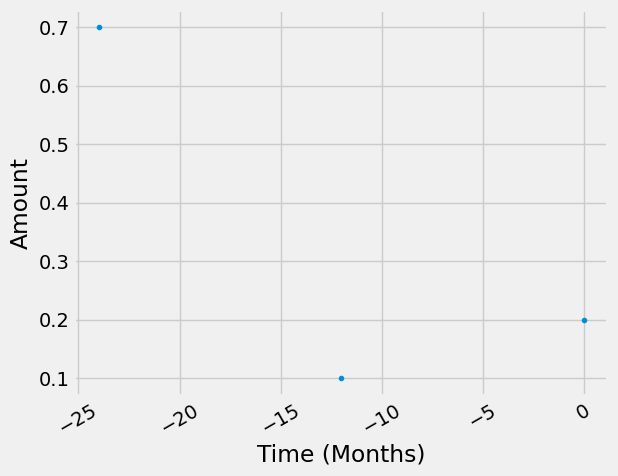

In [4]:
td_glider_production.graph(resolution="M")

Now we attach the temporal distributions to the exchanges they belong to. The helper function `add_temporal_distribution_to_exchange` from `bw_timex.utils` finds an exchange for you, based on the process it comes from (`input_...`) and the process it goes to (`output_...`). We identify the processes by their name and database here, adding the location where the name alone is not unique.

In [5]:
from bw_timex.utils import add_temporal_distribution_to_exchange

add_temporal_distribution_to_exchange(
    td_glider_production,
    input_name="glider production, passenger car, without EOL",
    input_database=ev_background_2020.name,
    output_name="production of an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_powertrain_and_battery_production,
    input_name="powertrain production, for electric passenger car, without EOL",
    input_database=ev_background_2020.name,
    output_name="production of an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_powertrain_and_battery_production,
    input_name="battery production, Li-ion, LiMn2O4, rechargeable, without EOL",
    input_database=ev_background_2020.name,
    output_name="production of an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_assembly_and_delivery,
    input_name="production of an electric vehicle",
    input_database="foreground",
    output_name="driving an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_use_phase,
    input_name="market group for electricity, low voltage",
    input_database=db_2020.name,
    input_location="DEU",
    output_name="driving an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_disassemble_used_ev,
    input_name="used electric vehicle",
    input_database="foreground",
    output_name="driving an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_treating_waste,
    input_name="treatment of used glider, passenger car, shredding",
    input_database=db_2020.name,
    output_name="used electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_treating_waste,
    input_name="treatment of used powertrain for electric passenger car, manual dismantling",
    input_database=db_2020.name,
    output_name="used electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_treating_waste,
    input_name="market for used Li-ion battery",
    input_database=db_2020.name,
    output_name="used electric vehicle",
    output_database="foreground",
)

2026-08-04 07:10:04.975 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 840 kilogram 'glider production, passenger car, without EOL' (kilogram, GLO, None) to 'production of an electric vehicle' (unit, GLO, None).
2026-08-04 07:10:04.980 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 80 kilogram 'powertrain production, for electric passenger car, without EOL' (kilogram, GLO, None) to 'production of an electric vehicle' (unit, GLO, None).
2026-08-04 07:10:04.985 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 280 kilogram 'battery production, Li-ion, LiMn2O4, rechargeable, without EOL' (kilogram, GLO, None) to 'production of an electric vehicle' (unit, GLO, None).
2026-08-04 07:10:04.989 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temp

## Time-explicit LCA

Besides the functional unit and the impact assessment method, `bw_timex` needs to know which point in time each background database represents. Databases that carry temporal distributions - here our foreground - are flagged as `"dynamic"`.

In [6]:
from datetime import datetime

functional_unit = {driving: 1}  # transport over 1 ev lifetime

method = ("ecoinvent-3.12", "EF v3.1", "climate change", "global warming potential (GWP100)")

database_dates = {
    db_2020.name: datetime.strptime("2020", "%Y"),
    db_2030.name: datetime.strptime("2030", "%Y"),
    db_2040.name: datetime.strptime("2040", "%Y"),
    "ev_background_2020": datetime.strptime("2020", "%Y"),
    "ev_background_2030": datetime.strptime("2030", "%Y"),
    "ev_background_2040": datetime.strptime("2040", "%Y"),
    "foreground": "dynamic",
}

With that, we can set up a `TimexLCA`. It works like a normal `bw2calc.LCA`, with `database_dates` as the extra argument:

In [7]:
from bw_timex import TimexLCA

tlca = TimexLCA(functional_unit, method, database_dates)

2026-08-04 07:10:08.209 | INFO     | bw_timex.timex_lca:__init__:142 - Initializing TimexLCA object...
2026-08-04 07:10:08.210 | INFO     | bw_timex.timex_lca:__init__:163 - Calculating base LCA...
2026-08-04 07:10:08.210 | INFO     | bw_timex.timex_lca:clean_databases:1214 - Reprocessing 1 modified database(s) before calculating: foreground. This can take a while for large databases.
2026-08-04 07:10:08.219 | INFO     | bw_timex.timex_lca:clean_databases:1220 - Done reprocessing modified databases.
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 3.90e+13)
  warnings.warn(msg, UmfpackWarning)
2026-08-04 07:10:08.947 | INFO     | bw_timex.timex_lca:__init__:180 - Collecting node infos...
2026-08-04 07:10:08.985 | INFO     | bw_timex.timex_lca:__init__:192 - Loading node metadata from 7 database(s)...
2026-08-04 07:10:09.793 | INFO     | bw_timex.timex_lca:__

First, `bw_timex` traverses the supply chain and collects when each process occurs in a timeline:

In [8]:
tlca.build_timeline(
    temporal_grouping="month", # aggregate timeline to next month
    graph_traversal="bfs", # breadth first traversal because foreground is relatively small
    )

2026-08-04 07:10:23.270 | INFO     | bw_timex.timex_lca:build_timeline:358 - No edge filter function provided. Skipping all edges in background databases.
2026-08-04 07:10:29.312 | INFO     | bw_timex.timex_lca:build_timeline:379 - Creating activity time mapping...
2026-08-04 07:10:29.413 | INFO     | bw_timex.timeline_builder:__init__:112 - Traversing supply chain graph...
2026-08-04 07:10:29.437 | INFO     | bw_timex.timeline_builder:build_timeline:186 - Building timeline...
2026-08-04 07:10:29.536 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:705 - Reference date 2040-08-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2024-05-01,"glider production, passenger car, without EOL",2026-05-01,production of an electric vehicle,588.0,"{'ev_background_2020': 0.567, 'ev_background_2..."
1,2024-06-01,"glider production, passenger car, without EOL",2026-06-01,production of an electric vehicle,588.0,"{'ev_background_2020': 0.558, 'ev_background_2..."
2,2025-05-01,"glider production, passenger car, without EOL",2026-05-01,production of an electric vehicle,84.0,"{'ev_background_2020': 0.467, 'ev_background_2..."
3,2025-05-01,"powertrain production, for electric passenger ...",2026-05-01,production of an electric vehicle,80.0,"{'ev_background_2020': 0.467, 'ev_background_2..."
4,2025-05-01,"battery production, Li-ion, LiMn2O4, rechargea...",2026-05-01,production of an electric vehicle,280.0,"{'ev_background_2020': 0.467, 'ev_background_2..."
5,2025-06-01,"glider production, passenger car, without EOL",2026-06-01,production of an electric vehicle,84.0,"{'ev_background_2020': 0.459, 'ev_background_2..."
6,2025-06-01,"powertrain production, for electric passenger ...",2026-06-01,production of an electric vehicle,80.0,"{'ev_background_2020': 0.459, 'ev_background_2..."
7,2025-06-01,"battery production, Li-ion, LiMn2O4, rechargea...",2026-06-01,production of an electric vehicle,280.0,"{'ev_background_2020': 0.459, 'ev_background_2..."
8,2026-05-01,"glider production, passenger car, without EOL",2026-05-01,production of an electric vehicle,168.0,"{'ev_background_2020': 0.367, 'ev_background_2..."
9,2026-05-01,production of an electric vehicle,2026-08-01,driving an electric vehicle,0.2,None


Next, we calculate the time-explicit inventory. This relinks all processes to the background databases matching their timing:

In [9]:
tlca.lci()

2026-08-04 07:10:32.439 | INFO     | bw_timex.timex_lca:lci:529 - Expanding matrices...
2026-08-04 07:10:32.457 | INFO     | bw_timex.timex_lca:lci:548 - Calculating dynamic inventory...
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 4.97e+12)
  warnings.warn(msg, UmfpackWarning)
/Users/timodiepers/Documents/Coding/bw_timex/.venv/lib/python3.12/site-packages/scikits/umfpack/umfpack.py:737: UmfpackWarning: (almost) singular matrix! (estimated cond. number: 4.97e+12)
  warnings.warn(msg, UmfpackWarning)


Now we can get the time-explicit score, using the static characterization method we chose above:

In [10]:
tlca.static_lcia()
tlca.static_score  # kg CO2-eq

10744.473494732374

For comparison, a conventional LCA with a fixed background database (here: 2020) - `bw_timex` calculated this along the way:

In [11]:
tlca.base_lca.score  # kg CO2-eq

23247.15112358249

## Dynamic characterization

Since we know *when* each emission occurs, we can also characterize them dynamically, instead of lumping everything together at one point in time. `bw_timex` automatically maps the parameterized characterization functions from [`dynamic_characterization`](https://dynamic-characterization.readthedocs.io/en/latest/) (based on IPCC AR6) to the ecoinvent biosphere flows:

In [12]:
tlca.dynamic_lcia(metric="GWP")
tlca.dynamic_score  # kg CO2-eq (GWP100)

2026-08-04 07:10:51.241 | INFO     | dynamic_characterization.dynamic_characterization:characterize:126 - No custom dynamic characterization functions provided. Using default dynamic             characterization functions. The flows that are characterized are based on the selection                of the initially chosen impact category.


np.float64(10655.763775235002)

And plot how that impact is distributed over time, stacked by the processes causing it:

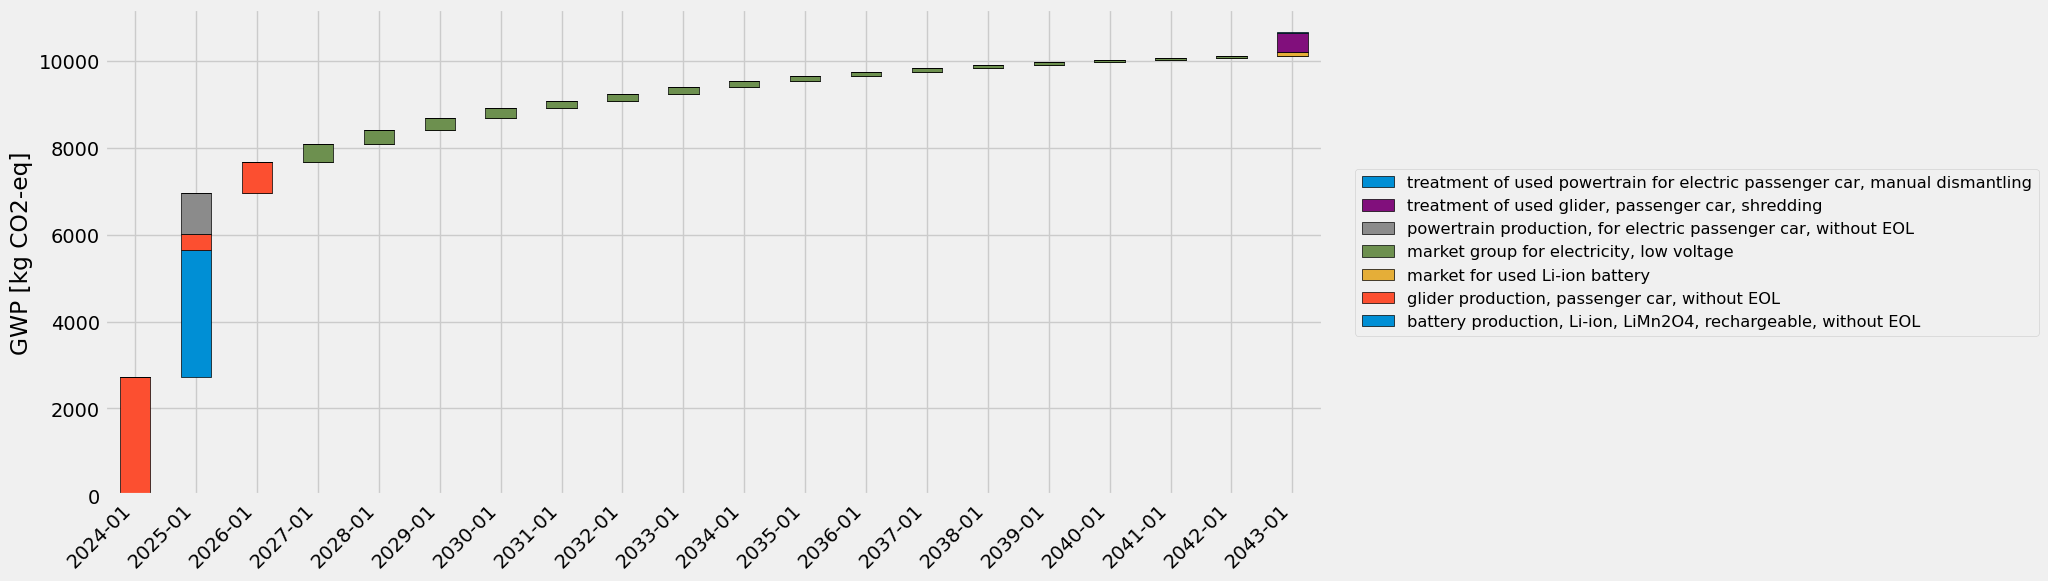

In [13]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall

plot_characterized_inventory_as_waterfall(tlca)

That's it: same modelling as a normal LCA, plus temporal distributions on the exchanges, and the background databases are chosen according to when things actually happen.

If you want to dig deeper - other temporal resolutions, custom graph traversal, radiative forcing as a metric, or a comparison against fully prospective results - have a look at the [detailed version](./electric_vehicle_premise_detailed.ipynb) of this example.